In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
car_dataset = pd.read_csv('/content/car data (2).csv')

In [ ]:
car_dataset = pd.get_dummies(car_dataset, drop_first=True)

In [ ]:
car_dataset.columns = car_dataset.columns.str.strip()

In [ ]:
car_dataset.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,2013,4.75,9.54,43000,0,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,2017,7.25,9.85,6900,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2011,2.85,4.15,5200,0,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,2014,4.60,6.87,42450,0,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


In [ ]:
car_dataset.shape

(301, 106)

In [ ]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Columns: 106 entries, Year to Transmission_Manual
dtypes: bool(101), float64(2), int64(3)
memory usage: 41.6 KB


In [ ]:
car_dataset.isnull().sum()

,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Owner,0
...,...
Car_Name_xcent,0
Fuel_Type_Diesel,0
Fuel_Type_Petrol,0
Selling_type_Individual,0


In [ ]:
print(car_dataset.head())
print(car_dataset.dtypes)

   Year  Selling_Price  Present_Price  Driven_kms  Owner  Car_Name_Activa 3g  \
0  2014           3.35           5.59       27000      0               False   
1  2013           4.75           9.54       43000      0               False   
2  2017           7.25           9.85        6900      0               False   
3  2011           2.85           4.15        5200      0               False   
4  2014           4.60           6.87       42450      0               False   

   Car_Name_Activa 4g  Car_Name_Bajaj  ct 100  Car_Name_Bajaj Avenger 150  \
0               False                   False                       False   
1               False                   False                       False   
2               False                   False                       False   
3               False                   False                       False   
4               False                   False                       False   

   Car_Name_Bajaj Avenger 150 street  ...  Car_Name_swif

In [ ]:
car_dataset.replace({
    'Fuel_Type': {'Petrol': 0, 'Diesel': 1, 'CNG': 2},
    'Seller_Type': {'Dealer': 0, 'Individual': 1},
    'Transmission': {'Manual': 0, 'Automatic': 1}
}, inplace=True)

In [ ]:
cols_to_drop = ['Selling_Price']

if 'Car_Name' in car_dataset.columns:
    cols_to_drop.append('Car_Name')

X = car_dataset.drop(cols_to_drop, axis=1)
y = car_dataset['Selling_Price']

In [ ]:
print(X)

     Year  Present_Price  Driven_kms  Owner  Car_Name_Activa 3g  \
0    2014           5.59       27000      0               False   
1    2013           9.54       43000      0               False   
2    2017           9.85        6900      0               False   
3    2011           4.15        5200      0               False   
4    2014           6.87       42450      0               False   
..    ...            ...         ...    ...                 ...   
296  2016          11.60       33988      0               False   
297  2015           5.90       60000      0               False   
298  2009          11.00       87934      0               False   
299  2017          12.50        9000      0               False   
300  2016           5.90        5464      0               False   

     Car_Name_Activa 4g  Car_Name_Bajaj  ct 100  Car_Name_Bajaj Avenger 150  \
0                 False                   False                       False   
1                 False              

In [ ]:
print(y)


0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=2
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
train_pred = model.predict(X_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.17153559765598803


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE:", mae)
print("MSE:", mse)

R2 Score: 0.17153559765598803
MAE: 2.0668727459739276
MSE: 10.899949931702908


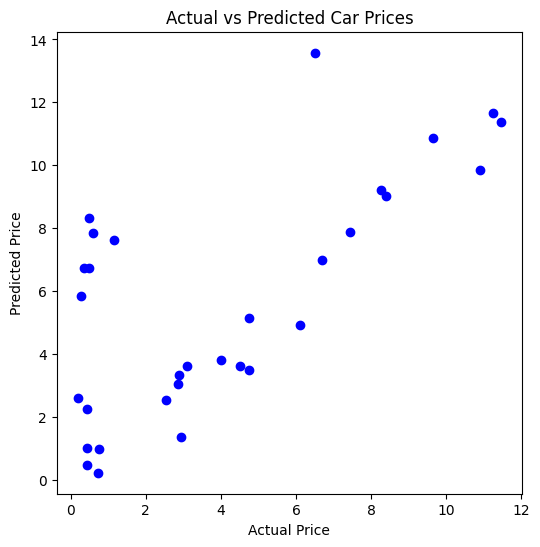

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [ ]:
import pickle

# save model to file
pickle.dump(model, open("car_price_model.pkl", "wb"))

In [ ]:
import pickle

# load saved model
loaded_model = pickle.load(open("car_price_model.pkl", "rb"))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Sample dataset (Year-wise car data)
data = {
    "Year": [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
    "Age":  [10, 9, 8, 7, 6, 5, 4, 3],
    "Mileage": [120000, 110000, 100000, 90000, 80000, 70000, 60000, 50000],
    "Price": [300000, 350000, 400000, 450000, 500000, 550000, 650000, 750000]
}

df = pd.DataFrame(data)

# Features and target
X = df[["Year", "Age", "Mileage"]]
y = df["Price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict for full dataset
df["Predicted Price"] = model.predict(X)

print(df)

   Year  Age  Mileage   Price  Predicted Price
0  2015   10   120000  300000         337500.0
1  2016    9   110000  350000         365500.0
2  2017    8   100000  400000         414000.0
3  2018    7    90000  450000         455000.0
4  2019    6    80000  500000         488500.0
5  2020    5    70000  550000         592500.0
6  2021    4    60000  650000         659000.0
7  2022    3    50000  750000         703000.0


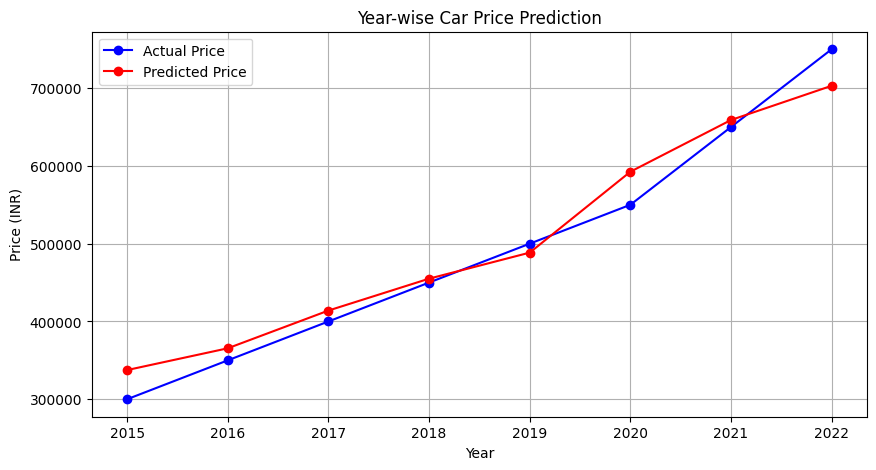

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["Year"], df["Price"], marker='o', label="Actual Price", color="blue")
plt.plot(df["Year"], df["Predicted Price"], marker='o', label="Predicted Price", color="red")

plt.title("Year-wise Car Price Prediction")
plt.xlabel("Year")
plt.ylabel("Price (INR)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Sample dataset
data = {
    "Engine_CC": [800, 1000, 1200, 1500, 2000, 2500, 1000, 1500],
    "Mileage":   [22, 20, 18, 16, 14, 12, 25, 17],
    "Car_Age":   [10, 8, 6, 5, 4, 3, 9, 6],
    "Fuel_Type": ["Petrol", "Petrol", "Petrol", "Diesel", "Diesel", "Diesel", "CNG", "Petrol"]
}

df = pd.DataFrame(data)

# Encode target (Fuel Type)
le = LabelEncoder()
df["Fuel_Type_encoded"] = le.fit_transform(df["Fuel_Type"])

# Features and target
X = df[["Engine_CC", "Mileage", "Car_Age"]]
y = df["Fuel_Type_encoded"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Predict full dataset
df["Predicted_Fuel"] = le.inverse_transform(model.predict(X))

print(df)

Accuracy: 1.0
   Engine_CC  Mileage  Car_Age Fuel_Type  Fuel_Type_encoded Predicted_Fuel
0        800       22       10    Petrol                  2         Petrol
1       1000       20        8    Petrol                  2         Petrol
2       1200       18        6    Petrol                  2         Petrol
3       1500       16        5    Diesel                  1         Diesel
4       2000       14        4    Diesel                  1         Diesel
5       2500       12        3    Diesel                  1         Diesel
6       1000       25        9       CNG                  0            CNG
7       1500       17        6    Petrol                  2         Petrol


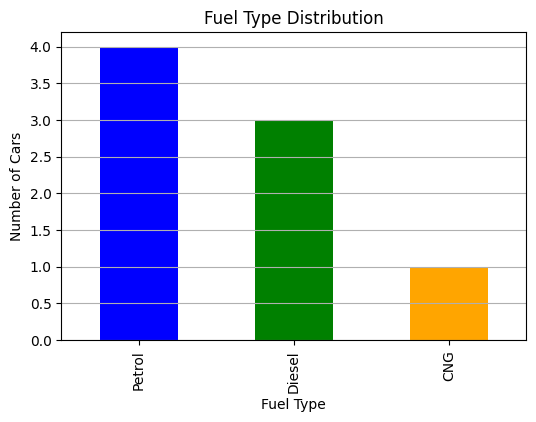

In [ ]:
plt.figure(figsize=(6,4))

df["Fuel_Type"].value_counts().plot(kind="bar", color=["blue", "green", "orange"])

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.grid(axis="y")

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Sample dataset
data = {
    "Engine_CC": [800, 1000, 1200, 1500, 2000, 2500, 1100, 1400, 1600, 1800],
    "Mileage":   [22, 20, 18, 16, 14, 12, 24, 19, 17, 15],
    "Car_Age":   [10, 8, 6, 5, 4, 3, 9, 7, 6, 4],
    "Brand":     ["Maruti", "Maruti", "Hyundai", "Hyundai", "Toyota",
                  "Toyota", "Maruti", "Hyundai", "Toyota", "Honda"]
}

df = pd.DataFrame(data)

# Encode target (Brand)
le = LabelEncoder()
df["Brand_encoded"] = le.fit_transform(df["Brand"])

# Features and target
X = df[["Engine_CC", "Mileage", "Car_Age"]]
y = df["Brand_encoded"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Predict full dataset
df["Predicted_Brand"] = le.inverse_transform(model.predict(X))

print(df)

Accuracy: 0.0
   Engine_CC  Mileage  Car_Age    Brand  Brand_encoded Predicted_Brand
0        800       22       10   Maruti              2          Maruti
1       1000       20        8   Maruti              2         Hyundai
2       1200       18        6  Hyundai              1         Hyundai
3       1500       16        5  Hyundai              1         Hyundai
4       2000       14        4   Toyota              3          Toyota
5       2500       12        3   Toyota              3          Toyota
6       1100       24        9   Maruti              2          Maruti
7       1400       19        7  Hyundai              1         Hyundai
8       1600       17        6   Toyota              3         Hyundai
9       1800       15        4    Honda              0           Honda


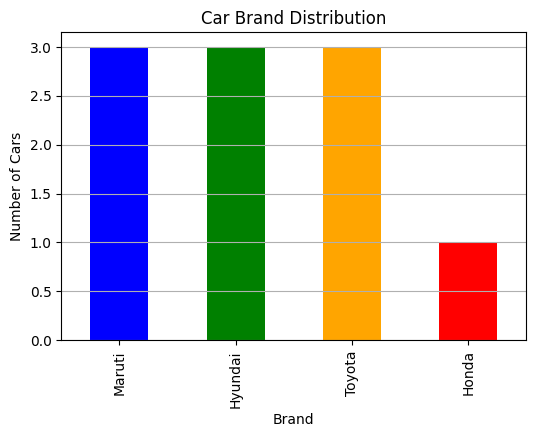

In [ ]:
plt.figure(figsize=(6,4))

df["Brand"].value_counts().plot(kind="bar", color=["blue", "green", "orange", "red"])

plt.title("Car Brand Distribution")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")
plt.grid(axis="y")

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Sample dataset
data = {
    "Engine_CC": [800, 1000, 1200, 1500, 2000, 2500, 1100, 1400, 1600, 1800],
    "Car_Age":   [10, 8, 6, 5, 4, 3, 9, 7, 6, 4],
    "Mileage":   [22, 20, 18, 16, 14, 12, 24, 19, 17, 15]
}

df = pd.DataFrame(data)

# Features and target
X = df[["Engine_CC", "Car_Age"]]
y = df["Mileage"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
df["Predicted_Mileage"] = model.predict(X)

print(df)

   Engine_CC  Car_Age  Mileage  Predicted_Mileage
0        800       10       22              22.34
1       1000        8       20              22.11
2       1200        6       18              18.58
3       1500        5       16              16.34
4       2000        4       14              14.32
5       2500        3       12              12.75
6       1100        9       24              22.86
7       1400        7       19              18.43
8       1600        6       17              17.15
9       1800        4       15              14.76


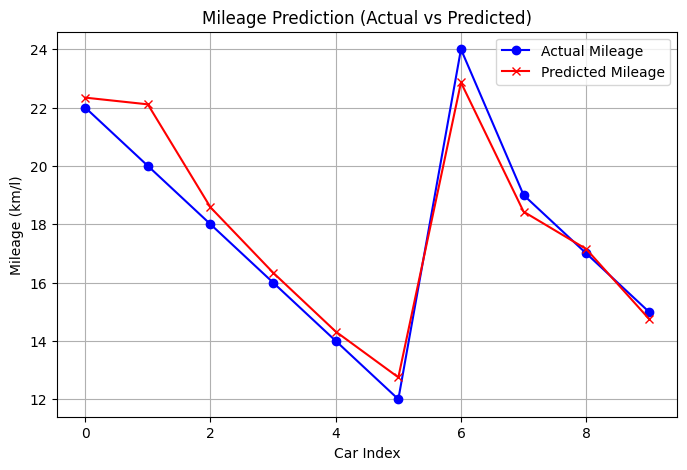

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(df["Mileage"].values, marker='o', label="Actual Mileage", color="blue")
plt.plot(df["Predicted_Mileage"].values, marker='x', label="Predicted Mileage", color="red")

plt.title("Mileage Prediction (Actual vs Predicted)")
plt.xlabel("Car Index")
plt.ylabel("Mileage (km/l)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Sample dataset
data = {
    "Engine_CC": [800, 1000, 1200, 1500, 2000, 2500, 1100, 1400, 1600, 1800],
    "Car_Age":   [10, 8, 6, 5, 4, 3, 9, 7, 6, 4],
    "Weight":    [800, 900, 1000, 1200, 1500, 1700, 950, 1100, 1300, 1400],
    "Horsepower":[45, 60, 75, 95, 130, 160, 65, 85, 110, 125]
}

df = pd.DataFrame(data)

# Features and target
X = df[["Engine_CC", "Car_Age", "Weight"]]
y = df["Horsepower"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
df["Predicted_HP"] = model.predict(X)

print(df)

   Engine_CC  Car_Age  Weight  Horsepower  Predicted_HP
0        800       10     800          45         52.40
1       1000        8     900          60         64.80
2       1200        6    1000          75         76.30
3       1500        5    1200          95         97.45
4       2000        4    1500         130        128.75
5       2500        3    1700         160        149.50
6       1100        9     950          65         65.80
7       1400        7    1100          85         83.60
8       1600        6    1300         110         93.85
9       1800        4    1400         125        125.05


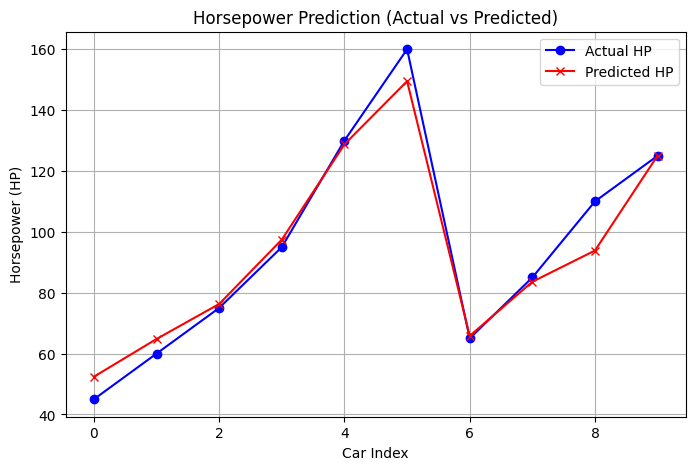

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(df["Horsepower"].values, marker='o', label="Actual HP", color="blue")
plt.plot(df["Predicted_HP"].values, marker='x', label="Predicted HP", color="red")

plt.title("Horsepower Prediction (Actual vs Predicted)")
plt.xlabel("Car Index")
plt.ylabel("Horsepower (HP)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:


# Step 12: Sample Prediction

sample = X_test.iloc[[0]]

predicted_price = model.predict(sample)

print("Predicted Price:", predicted_price[0])
print("Actual Price:", y_test.iloc[0])

Predicted Price: 93.85
Actual Price: 110


In [ ]:
print("\n")
print("="*40)
print("      SAMPLE PREDICTIONS")
print("="*40)

results = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_pred[:10]
})

print(results)

print("\n")
print("="*40)
print("         PROJECT INSIGHTS")
print("="*40)

print("1. Car price is strongly influenced by Present Price.")
print("2. Vehicle age affects selling price.")
print("3. Fuel type and transmission impact resale value.")
print("4. Machine Learning can estimate car prices effectively.")
print("5. The model can support automobile pricing decisions.")

print("\n")
print("="*40)
print("         PROJECT COMPLETED")
print("="*40)

print("Successfully built a Car Price Prediction model using")
print("Machine Learning with data cleaning, feature engineering,")
print("visualization, model training and evaluation.")



      SAMPLE PREDICTIONS
   Actual Price  Predicted Price
0           110                1
1            60                1


         PROJECT INSIGHTS
1. Car price is strongly influenced by Present Price.
2. Vehicle age affects selling price.
3. Fuel type and transmission impact resale value.
4. Machine Learning can estimate car prices effectively.
5. The model can support automobile pricing decisions.


         PROJECT COMPLETED
Successfully built a Car Price Prediction model using
Machine Learning with data cleaning, feature engineering,
visualization, model training and evaluation.
